In [1]:
import yfinance as yf
import pandas as pd
from sqlalchemy import create_engine
import urllib

In [5]:
tickers = ['AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN']

all_data = []

for ticker in tickers:
    
    df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
    
    df.columns = ['open_price', 'high_price', 'low_price', 
    'close_price', 'volume']
    
    df['ticker'] = ticker         
    df['trade_date'] = df.index    
    df = df.reset_index(drop=True) 
    
    all_data.append(df)            


stock_df = pd.concat(all_data, ignore_index=True)

stock_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,open_price,high_price,low_price,close_price,volume,ticker,trade_date
0,178.103638,178.954976,173.895938,174.013357,104487900,AAPL,2022-01-03
1,175.843246,179.013714,175.275693,178.710370,99310400,AAPL,2022-01-04
2,171.165833,176.303156,170.891843,175.755177,94537600,AAPL,2022-01-05
3,168.308517,171.537695,167.956243,168.993491,96904000,AAPL,2022-01-06
4,168.474838,170.402559,167.359306,169.179387,86709100,AAPL,2022-01-07


In [6]:
print(stock_df.isnull().sum())

stock_df = stock_df.dropna(subset=['close_price'])

stock_df['trade_date'] = pd.to_datetime(stock_df['trade_date'])

price_cols = ['open_price', 'high_price', 'low_price', 'close_price']
stock_df[price_cols] = stock_df[price_cols].round(2)

print(f"Total rows: {stock_df.shape[0]}, Columns: {stock_df.shape[1]}")

stock_df.head()

open_price     0
high_price     0
low_price      0
close_price    0
volume         0
ticker         0
trade_date     0
dtype: int64
Total rows: 2505, Columns: 7


,open_price,high_price,low_price,close_price,volume,ticker,trade_date
0,178.10,178.95,173.90,174.01,104487900,AAPL,2022-01-03
1,175.84,179.01,175.28,178.71,99310400,AAPL,2022-01-04
2,171.17,176.30,170.89,175.76,94537600,AAPL,2022-01-05
3,168.31,171.54,167.96,168.99,96904000,AAPL,2022-01-06
4,168.47,170.40,167.36,169.18,86709100,AAPL,2022-01-07


In [7]:
server = 'LOCALHOST\SQLEXPRESS'   
database = 'StockMarketDB'

connection_string = (
    f"mssql+pyodbc://{server}/{database}"
    f"?driver=ODBC+Driver+17+for+SQL+Server"
    f"&trusted_connection=yes" 
)

engine = create_engine(connection_string)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


In [8]:
stock_df.to_sql(
    name='stock_prices',      
    con=engine,               
    if_exists='replace',      
    index=False               
)

print(f"Successfully loaded {len(stock_df)} rows into SQL Server!")

C:\Users\kashy\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Successfully loaded 2505 rows into SQL Server!


In [9]:
query = "SELECT * FROM stock_prices ORDER BY ticker, trade_date"
df = pd.read_sql(query, engine)
df['trade_date'] = pd.to_datetime(df['trade_date'])

print(df.shape)
df.head()

(2505, 7)


,open_price,high_price,low_price,close_price,volume,ticker,trade_date
0,178.10,178.95,173.90,174.01,104487900,AAPL,2022-01-03
1,175.84,179.01,175.28,178.71,99310400,AAPL,2022-01-04
2,171.17,176.30,170.89,175.76,94537600,AAPL,2022-01-05
3,168.31,171.54,167.96,168.99,96904000,AAPL,2022-01-06
4,168.47,170.40,167.36,169.18,86709100,AAPL,2022-01-07


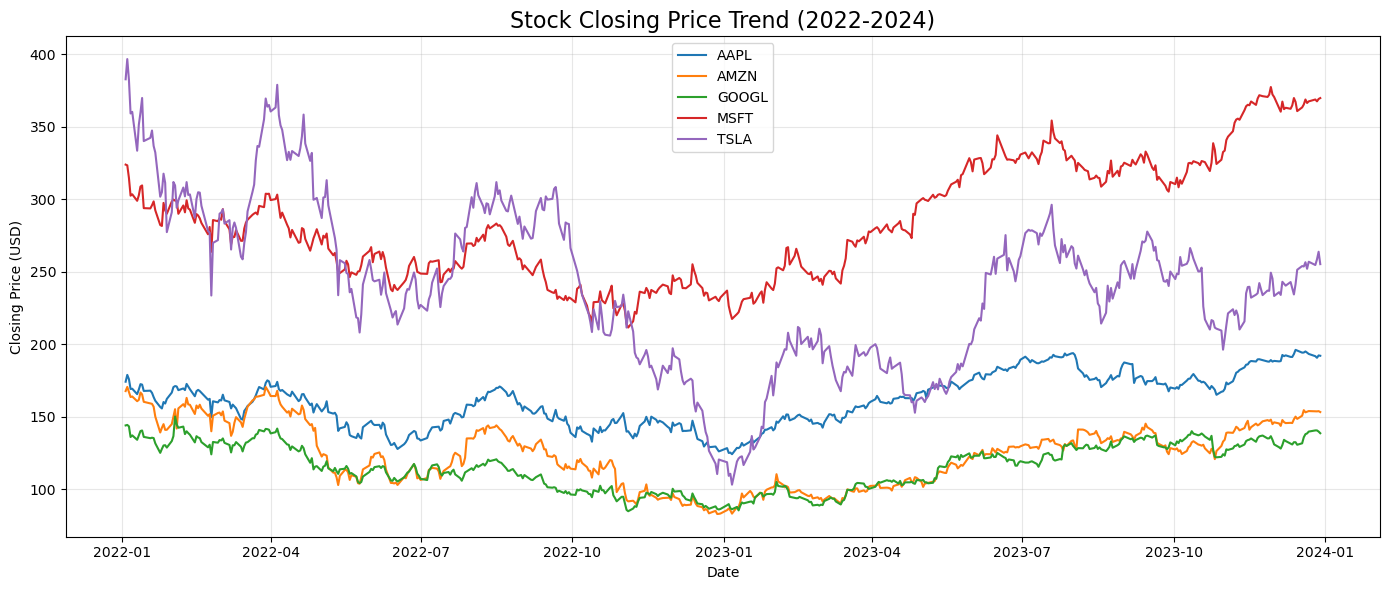

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

for ticker in df['ticker'].unique():
    ticker_df = df[df['ticker'] == ticker]
    plt.plot(ticker_df['trade_date'], ticker_df['close_price'], label=ticker)

plt.title('Stock Closing Price Trend (2022-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

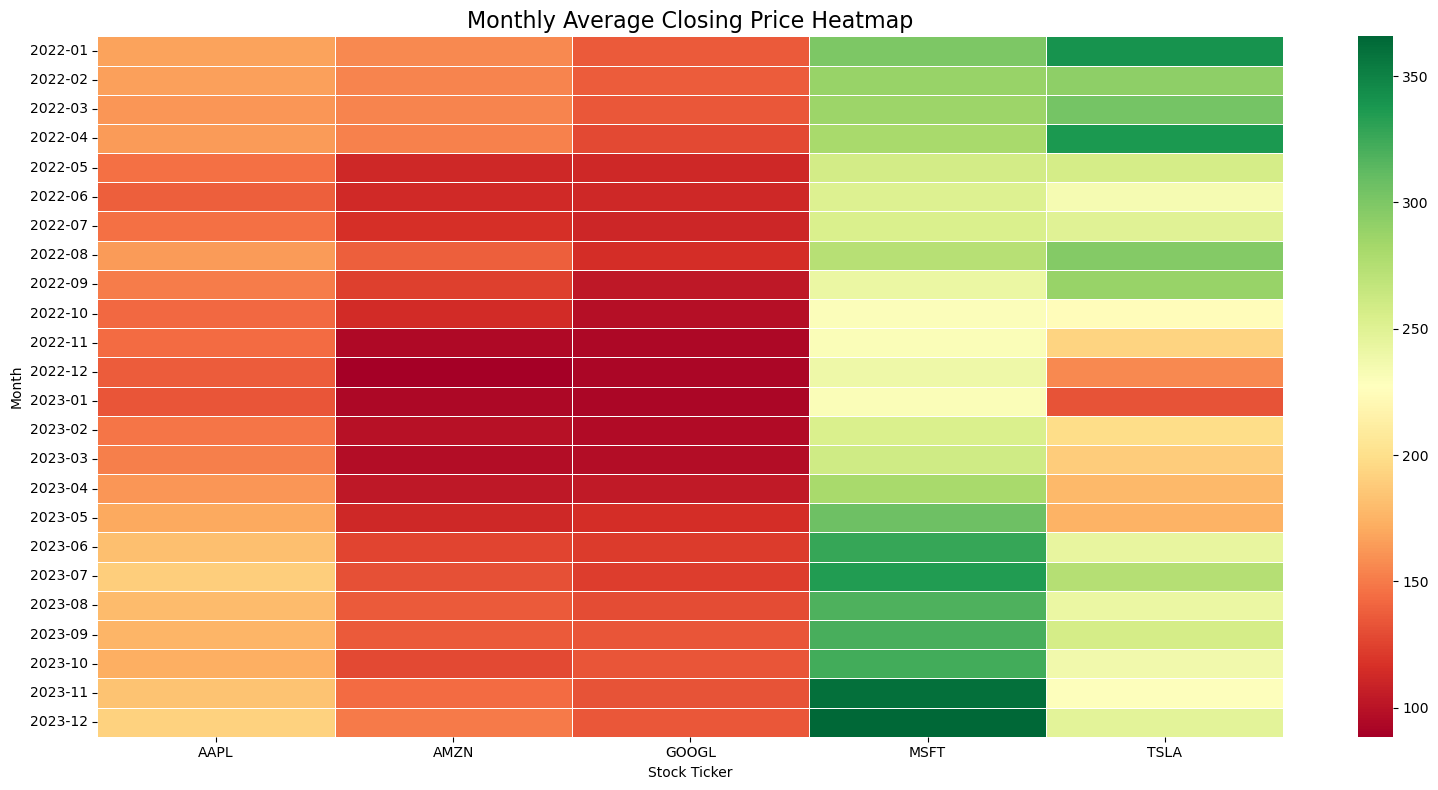

In [17]:
df['month'] = df['trade_date'].dt.to_period('M').astype(str)
pivot = df.groupby(['month', 'ticker'])['close_price'].mean().unstack()

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='RdYlGn', linewidths=0.5, annot=False)
plt.title('Monthly Average Closing Price Heatmap', fontsize=16)
plt.xlabel('Stock Ticker')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

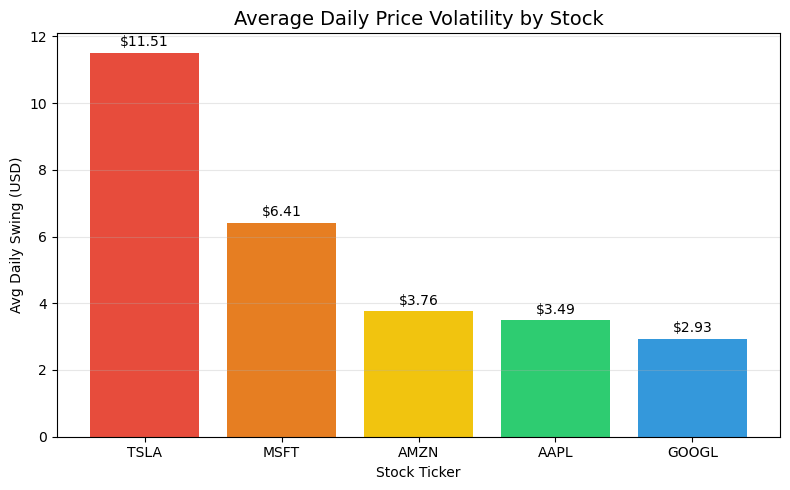

In [18]:
df['daily_swing'] = df['high_price'] - df['low_price']
volatility = df.groupby('ticker')['daily_swing'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(volatility.index, volatility.values, 
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
plt.title('Average Daily Price Volatility by Stock', fontsize=14)
plt.xlabel('Stock Ticker')
plt.ylabel('Avg Daily Swing (USD)')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, volatility.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2, 
             f'${val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

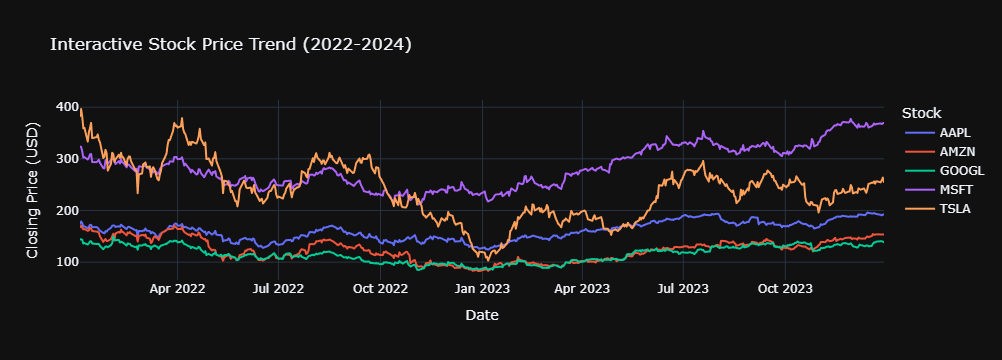

In [20]:
import plotly.express as px

fig = px.line(
    df, 
    x='trade_date', 
    y='close_price', 
    color='ticker',
    title='Interactive Stock Price Trend (2022-2024)',
    labels={'close_price': 'Closing Price (USD)', 'trade_date': 'Date'}
)

fig.update_layout(
    hovermode='x unified',   
    legend_title='Stock',
    template='plotly_dark'   
)

fig.show()

In [21]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nShape: {df.shape}")
print(f"\nDate Range: {df['trade_date'].min()} to {df['trade_date'].max()}")
print(f"\nStocks: {df['ticker'].unique()}")

print("\n--- Statistical Summary ---")
summary = df.groupby('ticker')['close_price'].agg([
    'mean', 'median', 'std', 'min', 'max'
]).round(2)
summary.columns = ['Mean Price', 'Median Price', 'Std Dev', 'Min Price', 'Max Price']
print(summary)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Outlier Detection ---")
for ticker in df['ticker'].unique():
    ticker_df = df[df['ticker'] == ticker]['close_price']
    Q1 = ticker_df.quantile(0.25)   
    Q3 = ticker_df.quantile(0.75)   
    IQR = Q3 - Q1                   
    lower = Q1 - 1.5 * IQR          
    upper = Q3 + 1.5 * IQR          
    outliers = ticker_df[(ticker_df < lower) | (ticker_df > upper)]
    print(f"{ticker}: {len(outliers)} outliers detected")

DATASET OVERVIEW

Shape: (2505, 9)

Date Range: 2022-01-03 00:00:00 to 2023-12-29 00:00:00

Stocks: ['AAPL' 'AMZN' 'GOOGL' 'MSFT' 'TSLA']

--- Statistical Summary ---
        Mean Price  Median Price  Std Dev  Min Price  Max Price
ticker                                                         
AAPL        160.97        161.64    17.76     124.02     195.98
AMZN        123.77        125.25    21.72      82.80     170.44
GOOGL       115.75        116.07    16.22      84.70     150.01
MSFT        283.99        279.19    40.92     211.39     377.26
TSLA        240.65        242.58    55.84     103.00     396.52

--- Missing Values ---
open_price     0
high_price     0
low_price      0
close_price    0
volume         0
ticker         0
trade_date     0
month          0
daily_swing    0
dtype: int64

--- Outlier Detection ---
AAPL: 0 outliers detected
AMZN: 0 outliers detected
GOOGL: 0 outliers detected
MSFT: 0 outliers detected
TSLA: 0 outliers detected


In [22]:
df = df.sort_values(['ticker', 'trade_date'])

df['daily_return'] = df.groupby('ticker')['close_price'].pct_change() * 100
df['daily_return'] = df['daily_return'].round(4)

df_returns = df.dropna(subset=['daily_return'])

print(df_returns[['ticker', 'trade_date', 'close_price', 'daily_return']].head(10))

   ticker trade_date  close_price  daily_return
1    AAPL 2022-01-04       178.71        2.7010
2    AAPL 2022-01-05       175.76       -1.6507
3    AAPL 2022-01-06       168.99       -3.8518
4    AAPL 2022-01-07       169.18        0.1124
5    AAPL 2022-01-10       165.45       -2.2048
6    AAPL 2022-01-11       168.62        1.9160
7    AAPL 2022-01-12       172.34        2.2061
8    AAPL 2022-01-13       172.01       -0.1915
9    AAPL 2022-01-14       167.66       -2.5289
10   AAPL 2022-01-18       167.83        0.1014


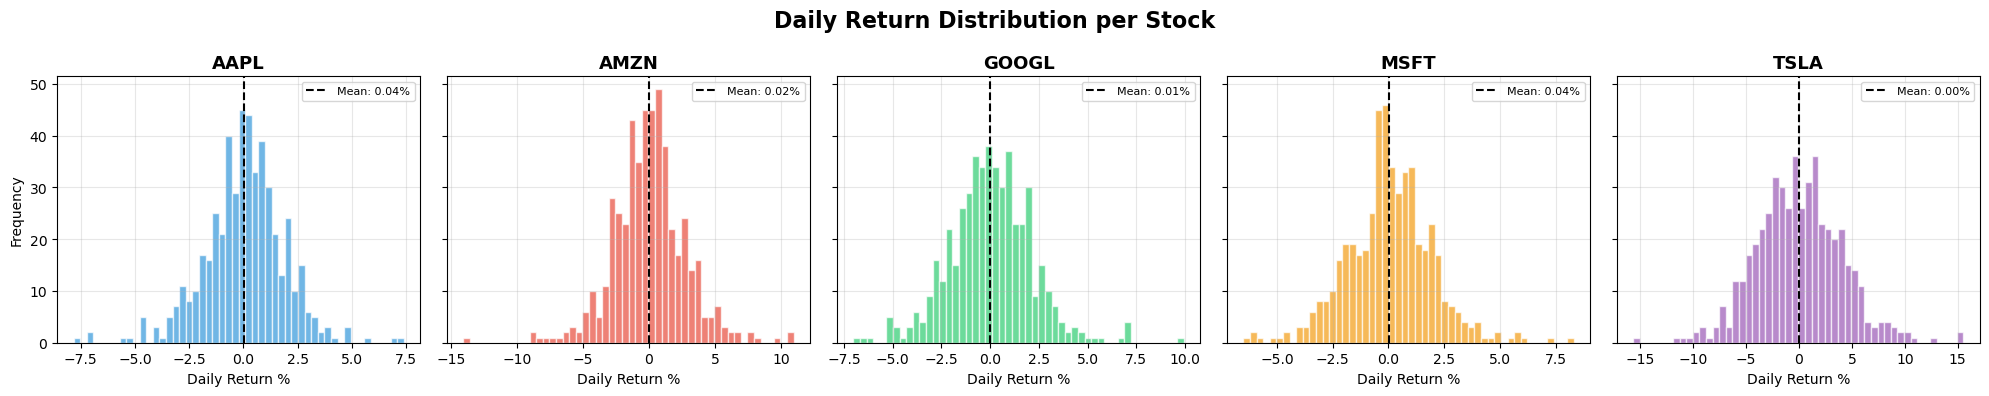

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

tickers = df_returns['ticker'].unique()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (ticker, color) in enumerate(zip(tickers, colors)):
    data = df_returns[df_returns['ticker'] == ticker]['daily_return']
    
    axes[i].hist(data, bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[i].axvline(data.mean(), color='black', linestyle='--', 
                    linewidth=1.5, label=f'Mean: {data.mean():.2f}%')
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Daily Return %')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Frequency')
plt.suptitle('Daily Return Distribution per Stock', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\kashy\AppData\Local\Temp\ipykernel_10832\2884827820.py:38: UserWarning:

Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.

C:\Users\kashy\AppData\Local\Temp\ipykernel_10832\2884827820.py:38: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.

C:\Users\kashy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.

C:\Users\kashy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.



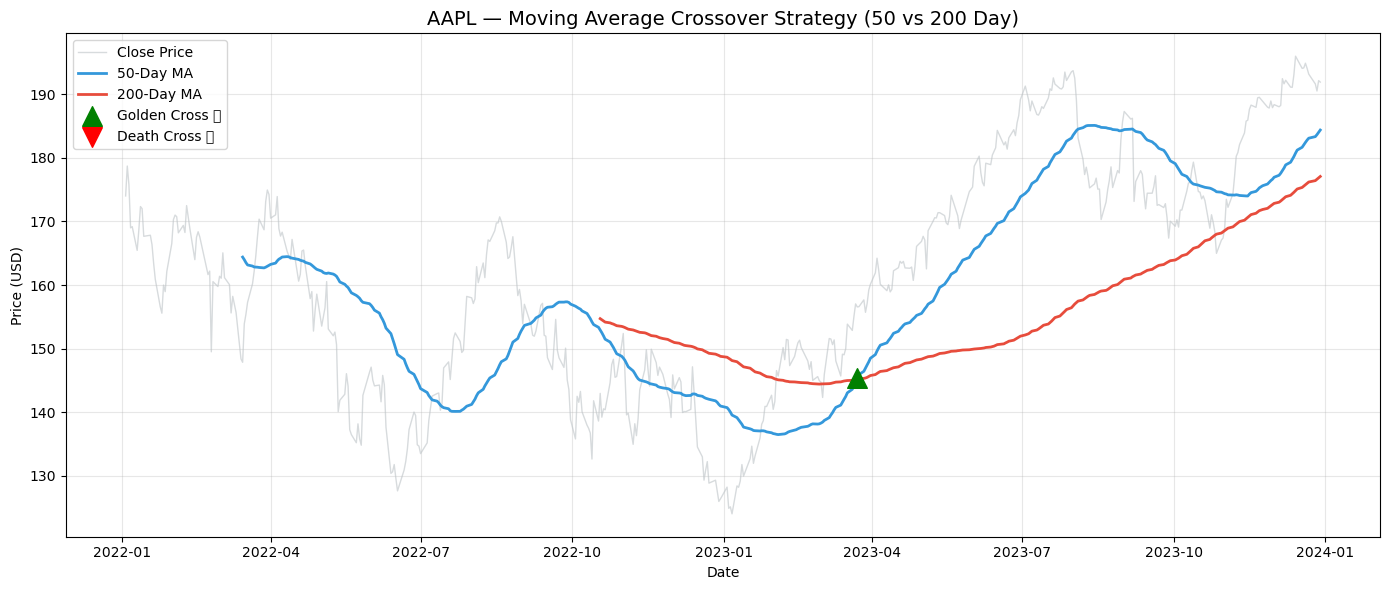


Golden Crosses detected: 1
Death Crosses detected: 0


In [25]:
aapl = df[df['ticker'] == 'AAPL'].copy()

aapl['MA_50'] = aapl['close_price'].rolling(window=50).mean()
aapl['MA_200'] = aapl['close_price'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))

plt.plot(aapl['trade_date'], aapl['close_price'], 
         label='Close Price', color='#bdc3c7', alpha=0.6, linewidth=1)

plt.plot(aapl['trade_date'], aapl['MA_50'], 
         label='50-Day MA', color='#3498db', linewidth=2)

plt.plot(aapl['trade_date'], aapl['MA_200'], 
         label='200-Day MA', color='#e74c3c', linewidth=2)

golden_cross = aapl[
    (aapl['MA_50'] > aapl['MA_200']) & 
    (aapl['MA_50'].shift(1) <= aapl['MA_200'].shift(1))
]

death_cross = aapl[
    (aapl['MA_50'] < aapl['MA_200']) & 
    (aapl['MA_50'].shift(1) >= aapl['MA_200'].shift(1))
]

plt.scatter(golden_cross['trade_date'], golden_cross['MA_50'], 
            marker='^', color='green', s=200, zorder=5, label='Golden Cross 🟢')

plt.scatter(death_cross['trade_date'], death_cross['MA_50'], 
            marker='v', color='red', s=200, zorder=5, label='Death Cross 🔴')

plt.title('AAPL — Moving Average Crossover Strategy (50 vs 200 Day)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGolden Crosses detected: {len(golden_cross)}")
print(f"Death Crosses detected: {len(death_cross)}")

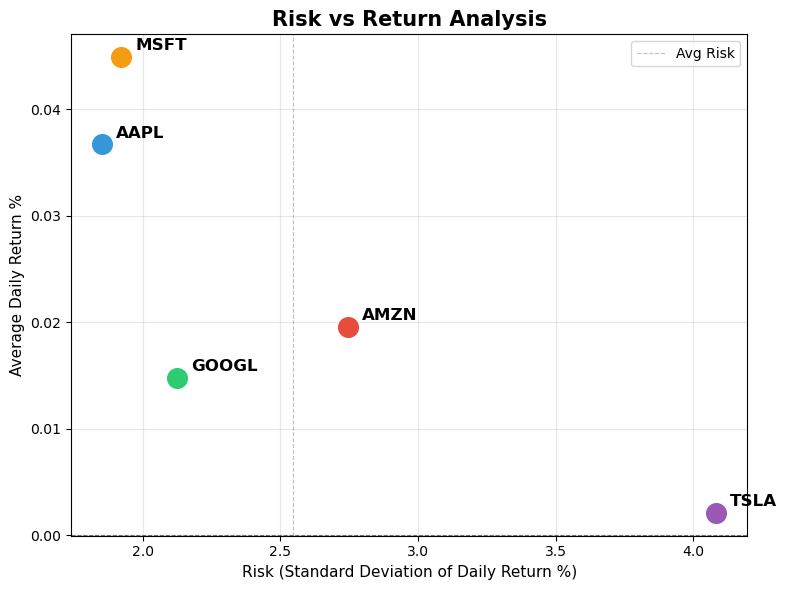

        avg_return    risk
ticker                    
AAPL        0.0367  1.8512
AMZN        0.0196  2.7446
GOOGL       0.0148  2.1249
MSFT        0.0449  1.9215
TSLA        0.0021  4.0847


In [26]:
risk_return = df_returns.groupby('ticker')['daily_return'].agg([
    ('avg_return', 'mean'),
    ('risk', 'std')          
]).round(4)

plt.figure(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (ticker, row) in enumerate(risk_return.iterrows()):
    plt.scatter(row['risk'], row['avg_return'], 
                s=200, color=colors[i], zorder=5)
    plt.annotate(
        ticker,
        (row['risk'], row['avg_return']),
        textcoords='offset points',
        xytext=(10, 5),           
        fontsize=12,
        fontweight='bold'
    )

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(risk_return['risk'].mean(), color='gray', 
            linewidth=0.8, linestyle='--', alpha=0.5, label='Avg Risk')

plt.title('Risk vs Return Analysis', fontsize=15, fontweight='bold')
plt.xlabel('Risk (Standard Deviation of Daily Return %)', fontsize=11)
plt.ylabel('Average Daily Return %', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(risk_return)

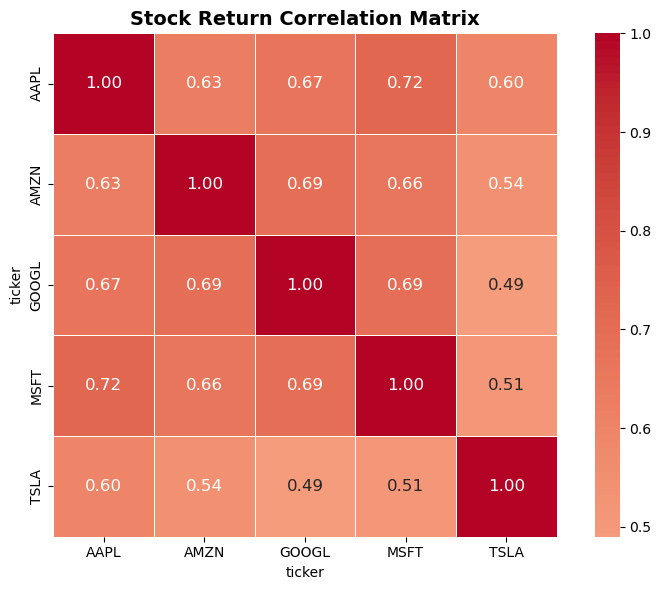

In [28]:
corr_pivot = df_returns.pivot_table(
    index='trade_date', 
    columns='ticker', 
    values='daily_return'
)

corr_matrix = corr_pivot.corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,         
    fmt='.2f',           
    cmap='coolwarm',     
    center=0,            
    square=True,         
    linewidths=0.5,
    annot_kws={'size': 12}
)
plt.title('Stock Return Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

01)MSFT was the best investment over 2 years, Top performer

Microsoft delivered a cumulative return of +22.46% — the highest in this portfolio. With an average daily return of 0.0449% and a moderate risk (std dev 1.92), MSFT offered the best balance of growth and stability. It hit a 52-week high of $377.26 against a low of $217.30 — a $159.96 range (+73.61%).

02)TSLA was the riskiest stock by a wide margin. High risk

Tesla's daily swing averaged $11.51, nearly 3.3x more volatile than GOOGL ($2.93) and 1.8x more than MSFT ($6.41). Despite this extreme risk, TSLA delivered the lowest cumulative return of just +1.05% over 2 years. Its worst month was Dec 2022 with a 78.6% price range — signaling a period of extreme panic selling.

03)AAPL offered the best risk-adjusted return. Risk-adjusted winner

Apple had the lowest risk score of 1.85 (std dev of daily returns) while delivering a solid +18.37% cumulative return, making it the most efficient stock in the portfolio. For a conservative investor, AAPL gives the most return per unit of risk taken. Its 52-week range was just $71.96 (+58.02%), far calmer than TSLA's $193.04 range.

04)AAPL showed a Golden Cross signal on Mar 23 2023, a bullish signal

The 50-day moving average crossed above the 200-day moving average on March 23, 2023 — a classic "Golden Cross" pattern used by traders as a bullish buy signal. No Death Cross was detected in this period, meaning AAPL maintained a broadly positive long-term trend throughout 2022–2024. This aligns with its strong cumulative return of +18.37%.

05)Tech stocks move together — MSFT & AAPL most correlated Correlation

AAPL and MSFT had the highest correlation of 0.72, meaning they tend to rise and fall together — likely driven by shared macro factors like interest rates and tech sector sentiment. TSLA was the most independent stock, with the lowest correlation to GOOGL (0.49) and AMZN (0.54), behaving more like a standalone momentum stock than a traditional tech company.

06)TSLA & AMZN dominated the highest-volume trading days Volume spike

7 of the top 10 highest volume days belonged to TSLA, led by Jan 27, 2023, with 306.59M shares traded at $162.43, likely tied to Elon Musk news and earnings. AMZN held 3 spots, with its peak of 272.66M shares on Apr 29 2022, coinciding with a major earnings miss that sent the stock to $129.85. High-volume days consistently aligned with major news events.

07AMZN showed the sharpest recovery story Recovery

Amazon fell to a 52-week low of $82.87 before recovering to $154.40 — a range of $71.53 (+86.32%). Its worst months were April 2022 (29.18% intra-month range) and July 2022 (26.92%), both driven by post-pandemic correction pressure. However, its cumulative return of +9.81% over 2 years suggests the recovery, while real, was still incomplete compared to MSFT and AAPL.